# MNIST Handwritten Digit Classifier 🔢

A complete end-to-end deep learning project using a **LeNet-style Convolutional Neural Network (CNN)**  
to classify handwritten digits (0–9) from the MNIST dataset.

---

## What you will learn

| Step | Topic |
|------|-------|
| 1 | Loading and inspecting the MNIST dataset |
| 2 | Understanding image representation |
| 3 | Data normalisation and reshaping |
| 4 | Building a CNN from scratch |
| 5 | Training with callbacks and learning rate scheduling |
| 6 | Evaluating with confusion matrix and classification report |
| 7 | Making predictions with confidence scores |

---

**Expected result:** ~99.2% accuracy on 10,000 test images

## Environment setup

Install all required packages if running for the first time.

In [ ]:
# Uncomment and run this cell once if packages are not installed
# !pip install tensorflow numpy matplotlib seaborn scikit-learn

---

# Step 1 — Load Data

## Theory

**MNIST** (Modified National Institute of Standards and Technology) is the "Hello World" of deep learning.  
It contains **70,000 grayscale images** of handwritten digits collected from American Census Bureau employees and high school students.

Key properties:
- 60,000 images for training, 10,000 for testing
- Each image is 28 × 28 pixels, grayscale (single channel)
- Labels are integers from 0 to 9
- Nearly balanced: each digit class has ~5,400–6,742 samples

## Mathematics

The dataset defines:

$$X_{\text{train}} \in \mathbb{R}^{60000 \times 28 \times 28}, \quad y_{\text{train}} \in \{0, 1, \ldots, 9\}^{60000}$$

$$X_{\text{test}} \in \mathbb{R}^{10000 \times 28 \times 28}, \quad y_{\text{test}} \in \{0, 1, \ldots, 9\}^{10000}$$

Each pixel value is an integer in $[0, 255]$ where 0 = black and 255 = white.

## TensorFlow implementation

`tf.keras.datasets.mnist.load_data()` downloads (~11 MB) and caches the dataset locally.  
It returns two tuples: `(X_train, y_train)` and `(X_test, y_test)`.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version     : {np.__version__}")

# ── Load MNIST ────────────────────────────────────────────────────────────────
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("\n── Dataset shapes ────────────────────────────")
print(f"X_train : {X_train.shape}  dtype: {X_train.dtype}")
print(f"y_train : {y_train.shape}  dtype: {y_train.dtype}")
print(f"X_test  : {X_test.shape}   dtype: {X_test.dtype}")
print(f"y_test  : {y_test.shape}   dtype: {y_test.dtype}")
print(f"\nPixel value range: {X_train.min()} – {X_train.max()}")

TensorFlow version: 2.21.0
NumPy version     : 2.3.5
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

── Dataset shapes ────────────────────────────
X_train : (60000, 28, 28)  dtype: uint8
y_train : (60000,)  dtype: uint8
X_test  : (10000, 28, 28)   dtype: uint8
y_test  : (10000,)   dtype: uint8

Pixel value range: 0 – 255


---

# Step 2 — Understand Images

## Theory

Before training any model, always **explore your data**. For image data, this means:

1. **Visualising samples** — spot mislabels, corrupted images, or unusual patterns
2. **Checking pixel statistics** — mean and standard deviation tell you how bright/dark images are on average
3. **Checking class balance** — imbalanced classes can bias the model toward majority classes

An image is just a 2D array of numbers. The spatial arrangement of those numbers encodes the digit shape.  
Bright pixels (high values) trace the pen strokes; dark pixels (low values) are background.

## Mathematics

A single image is a matrix:

$$X^{(i)} \in \mathbb{R}^{28 \times 28}, \quad X^{(i)}_{r,c} \in [0, 255]$$

To feed it into a dense layer (MLP), we flatten it to a vector:

$$x^{(i)} = \text{vec}(X^{(i)}) \in \mathbb{R}^{784}$$

For CNNs we keep the 2D structure — that is the whole point of convolutions.

Class probability (empirical):

$$p(\text{class} = k) = \frac{\text{count}(y = k)}{N} \approx 0.10 \quad \forall k \in \{0,\ldots,9\}$$

MNIST is nearly uniform, so no class-weighting tricks are needed.

## TensorFlow implementation

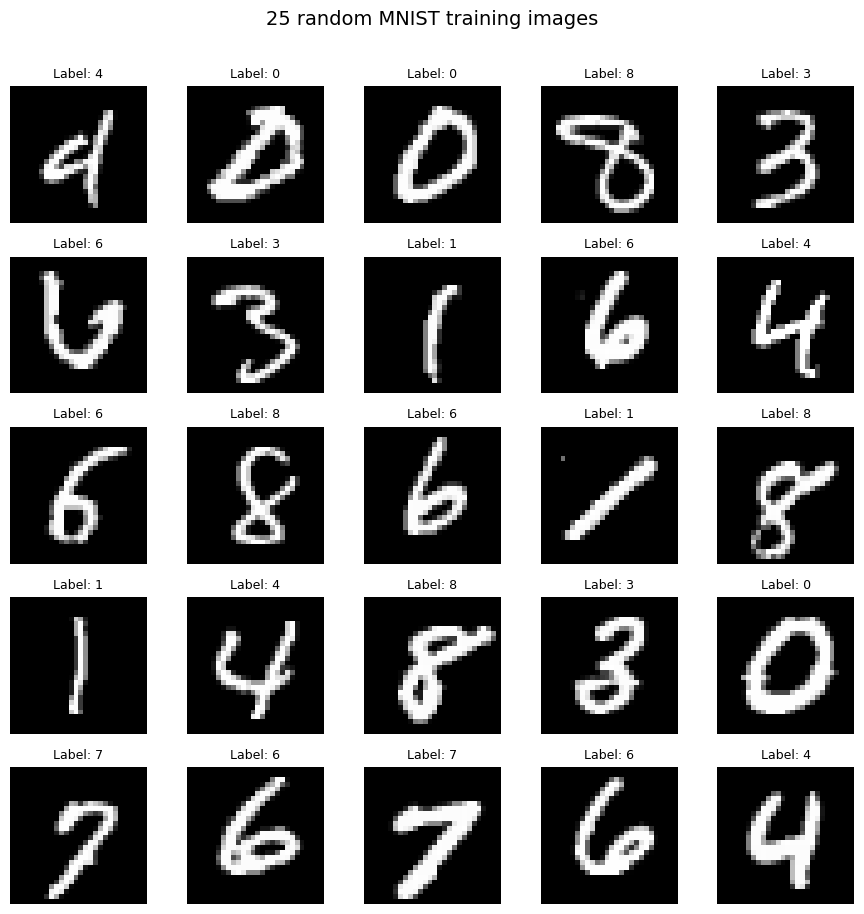

── Pixel statistics ──────────────────────────
Mean pixel value : 33.32
Std  pixel value : 78.57
Min / Max        : 0 / 255

── Class distribution ────────────────────────
  Digit 0:  5923 samples  █████████████████████████████
  Digit 1:  6742 samples  █████████████████████████████████
  Digit 2:  5958 samples  █████████████████████████████
  Digit 3:  6131 samples  ██████████████████████████████
  Digit 4:  5842 samples  █████████████████████████████
  Digit 5:  5421 samples  ███████████████████████████
  Digit 6:  5918 samples  █████████████████████████████
  Digit 7:  6265 samples  ███████████████████████████████
  Digit 8:  5851 samples  █████████████████████████████
  Digit 9:  5949 samples  █████████████████████████████


In [2]:
# ── Visualise 25 random training images ───────────────────────────────────────
np.random.seed(42)
fig, axes = plt.subplots(5, 5, figsize=(9, 9))
fig.suptitle("25 random MNIST training images", fontsize=14, y=1.01)

for ax in axes.flat:
    idx = np.random.randint(0, len(X_train))
    ax.imshow(X_train[idx], cmap='gray', interpolation='nearest')
    ax.set_title(f"Label: {y_train[idx]}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

# ── Pixel statistics ──────────────────────────────────────────────────────────
print("── Pixel statistics ──────────────────────────")
print(f"Mean pixel value : {X_train.mean():.2f}")
print(f"Std  pixel value : {X_train.std():.2f}")
print(f"Min / Max        : {X_train.min()} / {X_train.max()}")

# ── Class distribution ────────────────────────────────────────────────────────
unique, counts = np.unique(y_train, return_counts=True)
print("\n── Class distribution ────────────────────────")
for digit, count in zip(unique, counts):
    bar = '█' * (count // 200)
    print(f"  Digit {digit}: {count:5d} samples  {bar}")

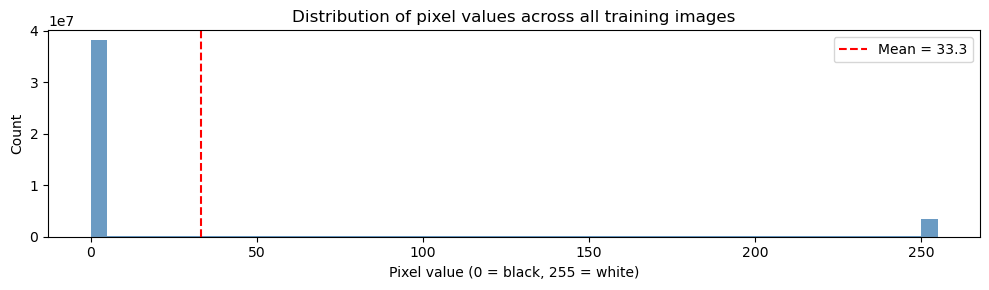

In [3]:
# ── Pixel value distribution histogram ───────────────────────────────────────
plt.figure(figsize=(10, 3))
plt.hist(X_train.ravel(), bins=50, color='steelblue', edgecolor='none', alpha=0.8)
plt.title('Distribution of pixel values across all training images')
plt.xlabel('Pixel value (0 = black, 255 = white)')
plt.ylabel('Count')
plt.axvline(X_train.mean(), color='red', linestyle='--', label=f'Mean = {X_train.mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

# Note: the strong spike near 0 is because most pixels are background (black)

**Key insight:** Most pixels are 0 (background). The small fraction of non-zero pixels forms the digit strokes. The model needs to learn which spatial patterns of bright pixels correspond to each digit.

---

# Step 3 — Data Normalisation

## Theory

Neural networks are sensitive to the scale of their inputs.  
Raw pixel values in [0, 255] cause several problems:

- **Large gradients** — weight updates overshoot, causing oscillation or divergence
- **Slow convergence** — the loss surface is poorly conditioned with unscaled inputs
- **Activation saturation** — large inputs push sigmoid/tanh into their flat regions

Normalising to [0.0, 1.0] resolves all of these. For MNIST, simple division by 255 is sufficient.  
More advanced projects use z-score standardisation: $(X - \mu) / \sigma$.

We also add a **channel dimension** because `Conv2D` expects inputs of shape `(H, W, C)` where `C` is the number of channels. MNIST images are grayscale, so C = 1.

## Mathematics

**Min-max normalisation** (applied here):

$$X_{\text{norm}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}} = \frac{X}{255} \quad \Rightarrow \quad X_{\text{norm}} \in [0.0, 1.0]$$

**Z-score standardisation** (alternative):

$$X_{\text{std}} = \frac{X - \mu}{\sigma} \quad \text{where } \mu \approx 33.3, \; \sigma \approx 78.6$$

This produces zero-mean, unit-variance inputs — useful for batch normalisation.

**Reshape** to add channel dimension:

$$(60000, 28, 28) \xrightarrow{\text{expand\_dims}} (60000, 28, 28, 1)$$

## TensorFlow implementation

In [4]:
# ── Cast to float32 and normalise ─────────────────────────────────────────────
# float32 is the standard dtype for neural network weights and activations.
# Using float64 doubles memory usage with no benefit on modern hardware.
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

print(f"After normalisation — Min: {X_train.min():.2f}, Max: {X_train.max():.2f}")
print(f"Mean: {X_train.mean():.4f}, Std: {X_train.std():.4f}")

# ── Add channel dimension ─────────────────────────────────────────────────────
# Conv2D requires input shape (batch, height, width, channels)
# The ... (Ellipsis) means "keep all existing dimensions"
# tf.newaxis inserts a new axis of size 1 at the last position
X_train = X_train[..., tf.newaxis]   # (60000, 28, 28) → (60000, 28, 28, 1)
X_test  = X_test[..., tf.newaxis]    # (10000, 28, 28) → (10000, 28, 28, 1)

print(f"\nFinal shapes:")
print(f"  X_train : {X_train.shape}  dtype: {X_train.dtype}")
print(f"  X_test  : {X_test.shape}   dtype: {X_test.dtype}")
print(f"  y_train : {y_train.shape}  dtype: {y_train.dtype}")
print(f"  y_test  : {y_test.shape}   dtype: {y_test.dtype}")

After normalisation — Min: 0.00, Max: 1.00
Mean: 0.1307, Std: 0.3081

Final shapes:
  X_train : (60000, 28, 28, 1)  dtype: float32
  X_test  : (10000, 28, 28, 1)   dtype: float32
  y_train : (60000,)  dtype: uint8
  y_test  : (10000,)   dtype: uint8


---

# Step 4 — Build the Neural Network

## Theory

We use a **Convolutional Neural Network (CNN)** — the standard architecture for image tasks.  
CNNs exploit two key properties of images:

1. **Translation invariance** — a digit '3' looks like a '3' regardless of where it appears in the image
2. **Spatial locality** — meaningful patterns (edges, curves) are formed by nearby pixels, not distant ones

A dense (MLP) network would treat every pixel independently and miss spatial structure entirely.  
A CNN uses **filters** that slide across the image, computing a dot product at each position.  
The same filter detects the same pattern anywhere in the image — this is **weight sharing**,  
which dramatically reduces parameters compared to a fully connected approach.

### Architecture overview

```
Input (28×28×1)
    ↓
Conv2D(32, 3×3, relu)  →  BatchNorm  →  MaxPool(2×2)  →  Dropout(0.25)
    ↓
Conv2D(64, 3×3, relu)  →  BatchNorm  →  MaxPool(2×2)  →  Dropout(0.25)
    ↓
Flatten → Dense(128, relu) → BatchNorm → Dropout(0.5)
    ↓
Dense(10, softmax)  →  Output probabilities
```

### Design decisions

| Layer | Reason for choice |
|-------|-------------------|
| 32 then 64 filters | Start with fewer features, increase depth in later layers |
| 3×3 kernel | Industry standard — captures local structure efficiently |
| `padding='same'` | Output size = input size; no information lost at borders |
| `BatchNormalization` | Normalises layer inputs; reduces internal covariate shift |
| `MaxPooling2D` | Halves spatial dimensions; provides translation invariance |
| `Dropout(0.25/0.5)` | Randomly zeros activations; prevents memorisation |
| `Dense(128)` | Combines all extracted features before classification |
| `softmax` output | Converts logits to valid probability distribution |

## Mathematics

### Convolution

For filter $f$ at position $(i, j)$ over input with $C$ channels:

$$Z[i, j, f] = \sum_{m=0}^{2} \sum_{n=0}^{2} \sum_{c=0}^{C-1} W[m, n, c, f] \cdot X[i+m,\; j+n,\; c] \;+\; b[f]$$

Each filter learns to detect a specific pattern. After training, filters in Block 1 detect edges and gradients. Filters in Block 2 detect curves, loops, and strokes.

### ReLU activation

$$A = \text{ReLU}(Z) = \max(0, Z)$$

Introduces non-linearity. Without it, stacking layers would be equivalent to one linear transformation.  
Dead neurons (always outputting 0) can occur if learning rate is too high.

### MaxPooling

$$P[i, j] = \max\!\left( Z[2i, 2j],\; Z[2i, 2j{+}1],\; Z[2i{+}1, 2j],\; Z[2i{+}1, 2j{+}1] \right)$$

Reduces spatial dimensions by 2×. Keeps only the strongest activation in each 2×2 window.

### Softmax

$$\hat{y}_k = \frac{\exp(z_k)}{\sum_{j=0}^{9} \exp(z_j)}, \quad k = 0, 1, \ldots, 9$$

Properties: $\hat{y}_k \in (0, 1)$ and $\sum_k \hat{y}_k = 1.0$ — a valid probability distribution.

### Sparse categorical cross-entropy loss

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \log\!\left( \hat{y}_{y^{(i)}} \right)$$

Only the log-probability of the **true class** contributes to the loss.  
"Sparse" means labels are integers (0–9), not one-hot vectors.

## TensorFlow implementation

In [5]:
from tensorflow.keras import layers, models

def build_model():
    """
    Builds and returns a LeNet-style CNN for MNIST digit classification.
    
    Architecture:
      Input (28,28,1)
      → Conv Block 1: Conv2D(32) + BN + MaxPool + Dropout
      → Conv Block 2: Conv2D(64) + BN + MaxPool + Dropout
      → Dense Head  : Flatten + Dense(128) + BN + Dropout
      → Output      : Dense(10, softmax)
    """
    model = models.Sequential([

        # ── Convolutional Block 1 ────────────────────────────────────────────
        # 32 filters, each 3×3, learn to detect edges and basic textures.
        # padding='same' ensures output H×W = input H×W (28×28 stays 28×28).
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            activation='relu',
            padding='same',
            input_shape=(28, 28, 1),
            name='conv1'
        ),
        # Normalise across the batch dimension at each spatial location.
        # Reduces internal covariate shift; acts as a regulariser.
        layers.BatchNormalization(name='bn1'),

        # Pool with 2×2 window, stride 2 → spatial dims halved: 28×28 → 14×14
        layers.MaxPooling2D(pool_size=(2, 2), name='pool1'),

        # Drop 25% of activations at random during training.
        # Forces the network to learn redundant representations.
        layers.Dropout(0.25, name='drop1'),

        # ── Convolutional Block 2 ────────────────────────────────────────────
        # 64 filters learn more complex patterns: curves, loops, digit strokes.
        # Input: 14×14×32 → Output: 14×14×64
        layers.Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation='relu',
            padding='same',
            name='conv2'
        ),
        layers.BatchNormalization(name='bn2'),

        # 14×14 → 7×7
        layers.MaxPooling2D(pool_size=(2, 2), name='pool2'),
        layers.Dropout(0.25, name='drop2'),

        # ── Classifier Head ──────────────────────────────────────────────────
        # Unroll 3D tensor (7×7×64 = 3,136 values) into a 1D vector.
        layers.Flatten(name='flatten'),

        # Fully connected layer: combines all extracted features.
        # 128 neurons is a balance between capacity and overfitting risk.
        layers.Dense(128, activation='relu', name='dense1'),
        layers.BatchNormalization(name='bn3'),

        # Higher dropout before output: 50% of neurons zeroed each forward pass.
        layers.Dropout(0.5, name='drop3'),

        # Output layer: 10 neurons (one per digit class).
        # Softmax converts raw scores to probabilities summing to 1.0.
        layers.Dense(10, activation='softmax', name='output')
    ])
    return model


model = build_model()
model.summary()

C:\Users\Shailesh\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                       │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn1 (BatchNormalization)             │ (None, 28, 28, 32)          │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop1 (Dropout)                      │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv2D)                       │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn2 (BatchNormalization)             │ (None, 14, 14, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop2 (Dropout)                      │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense1 (Dense)                       │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn3 (BatchNormalization)             │ (None, 128)                 │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop3 (Dropout)                      │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 422,538 (1.61 MB)

 Trainable params: 422,090 (1.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
# ── Verify output shape ───────────────────────────────────────────────────────
# Pass one dummy image through the model to confirm shapes are correct.
dummy = tf.zeros((1, 28, 28, 1))   # batch of 1 black image
out   = model(dummy, training=False)
print(f"Input  shape : {dummy.shape}")
print(f"Output shape : {out.shape}   ← should be (1, 10)")
print(f"Output probs : {out.numpy().round(4)}")
print(f"Sum of probs : {out.numpy().sum():.6f}  ← should be 1.0")

Input  shape : (1, 28, 28, 1)
Output shape : (1, 10)   ← should be (1, 10)
Output probs : [[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]]
Sum of probs : 1.000000  ← should be 1.0


---

# Step 5 — Training

## Theory

Training is the iterative process of adjusting the model's weights to minimise the loss function.

Each training iteration (one batch):
1. **Forward pass** — input travels through all layers; predictions are computed
2. **Loss computation** — compare predictions to true labels
3. **Backward pass (backpropagation)** — compute gradient of loss w.r.t. every weight
4. **Weight update** — move weights in the direction that reduces loss (via Adam)

One complete pass over all training data = one **epoch**.

### Why `validation_split=0.2`?

We hold out 20% of training data (12,000 images) as a **validation set**.  
The model never trains on this data — it is used only to measure generalisation after each epoch.  
If training accuracy rises but validation accuracy falls → **overfitting**.

### Callbacks

| Callback | What it does |
|----------|--------------|
| `ModelCheckpoint` | Saves model weights whenever `val_accuracy` improves |
| `ReduceLROnPlateau` | Halves learning rate if `val_loss` doesn't improve for 3 epochs |
| `EarlyStopping` | Stops training if `val_accuracy` stagnates for 5 epochs; restores best weights |

## Mathematics

### Backpropagation (chain rule)

For each weight $W$ in the network, the gradient of the loss is computed by chaining partial derivatives backwards from the output:

$$\frac{\partial \mathcal{L}}{\partial W} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial Z} \cdot \frac{\partial Z}{\partial W}$$

### Adam optimiser

Adam combines **momentum** (smooths gradient direction) and **RMSProp** (adapts step size per parameter):

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t \qquad \text{(1st moment — momentum)}$$

$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \qquad \text{(2nd moment — variance)}$$

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t} \qquad \text{(bias correction)}$$

$$W_t = W_{t-1} - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \varepsilon}$$

Default hyperparameters: $\alpha = 0.001$, $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\varepsilon = 10^{-7}$

## TensorFlow implementation

In [7]:
# ── Compile ───────────────────────────────────────────────────────────────────
model.compile(
    # Adam: adaptive learning rates per parameter — default for most DL tasks.
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),

    # 'sparse_categorical_crossentropy': use when labels are integers (0–9).
    # Use 'categorical_crossentropy' if labels are one-hot encoded.
    loss='sparse_categorical_crossentropy',

    # Track accuracy on each batch and report it at end of epoch.
    metrics=['accuracy']
)

print("Model compiled successfully.")
print(f"Optimizer : Adam  (lr=0.001)")
print(f"Loss      : sparse_categorical_crossentropy")
print(f"Metrics   : accuracy")

Model compiled successfully.
Optimizer : Adam  (lr=0.001)
Loss      : sparse_categorical_crossentropy
Metrics   : accuracy


In [8]:
# ── Callbacks ─────────────────────────────────────────────────────────────────
callbacks = [

    # Save model weights whenever validation accuracy improves.
    # 'save_best_only=True' means only the single best checkpoint is kept.
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_mnist.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    # If validation loss doesn't improve for 'patience' epochs, halve the LR.
    # This helps the model escape local minima it can no longer leave with the
    # current step size.
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,          # new_lr = lr * factor
        patience=3,          # wait 3 epochs before reducing
        min_lr=1e-6,         # never reduce below this floor
        verbose=1
    ),

    # Stop training early if val_accuracy hasn't improved in 5 epochs.
    # restore_best_weights=True reloads the best checkpoint automatically.
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

print("Callbacks registered:")
for cb in callbacks:
    print(f"  • {cb.__class__.__name__}")

Callbacks registered:
  • ModelCheckpoint
  • ReduceLROnPlateau
  • EarlyStopping


In [9]:
# ── Train ─────────────────────────────────────────────────────────────────────
# epochs=10       : maximum 10 full passes over training data
# batch_size=128  : process 128 images per gradient update
# validation_split: reserve last 20% of training set as validation data

print("Starting training...")
print(f"Training on {int(60000 * 0.8):,} images  |  Validating on {int(60000 * 0.2):,} images")
print(f"Batch size: 128  |  Max epochs: 10")
print("-" * 60)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Starting training...
Training on 48,000 images  |  Validating on 12,000 images
Batch size: 128  |  Max epochs: 10
------------------------------------------------------------
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8425 - loss: 0.5280
Epoch 1: val_accuracy improved from None to 0.47883, saving model to best_mnist.keras

Epoch 1: finished saving model to best_mnist.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 54s 137ms/step - accuracy: 0.9209 - loss: 0.2590 - val_accuracy: 0.4788 - val_loss: 1.7718 - learning_rate: 0.0010
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9681 - loss: 0.1032
Epoch 2: val_accuracy improved from 0.47883 to 0.98258, saving model to best_mnist.keras

Epoch 2: finished saving model to best_mnist.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 117ms/step - accuracy: 0.9709 - loss: 0.0944 - val_accuracy: 0.9826 - val_loss: 0.0573 - learning_rate: 0.0010
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9772 - loss: 0

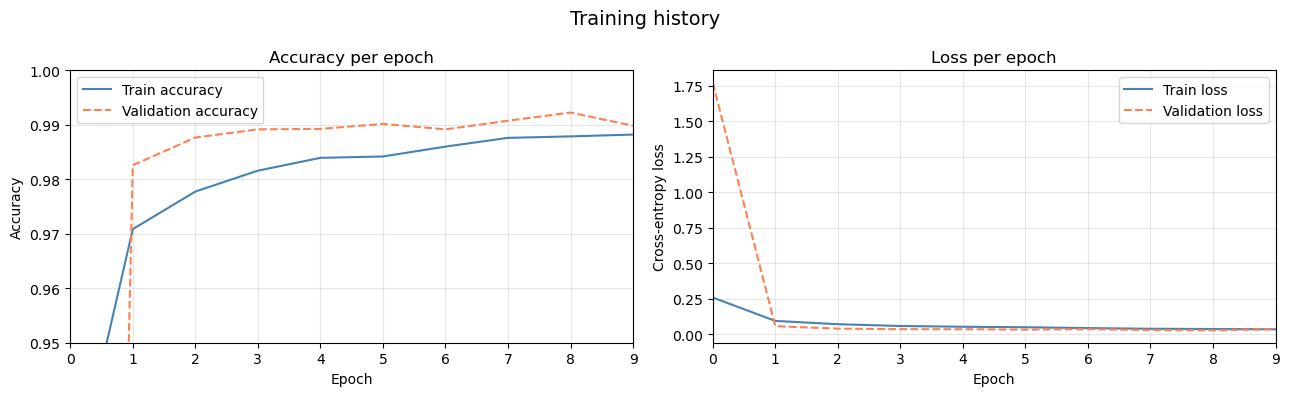


Best validation accuracy: 0.9923  (epoch 9)


In [11]:
# ── Plot training curves ──────────────────────────────────────────────────────
# A good model shows: both train and val accuracy rising together,
# then plateauing. If train >> val → overfitting. If both low → underfitting.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs_ran = len(history.history['accuracy'])

# Accuracy plot
ax1.plot(history.history['accuracy'],     label='Train accuracy',      color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Validation accuracy', color='coral', linestyle='--')
ax1.set_title('Accuracy per epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_xlim(0, epochs_ran - 1)
ax1.set_ylim(0.95, 1.00)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'],     label='Train loss',      color='steelblue')
ax2.plot(history.history['val_loss'], label='Validation loss', color='coral', linestyle='--')
ax2.set_title('Loss per epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Cross-entropy loss')
ax2.set_xlim(0, epochs_ran - 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training history', fontsize=14)
plt.tight_layout()
plt.show()

# Print best metrics
best_val_acc = max(history.history['val_accuracy'])
best_epoch   = history.history['val_accuracy'].index(best_val_acc) + 1
print(f"\nBest validation accuracy: {best_val_acc:.4f}  (epoch {best_epoch})")

---

# Step 6 — Evaluation

## Theory

After training, we evaluate the model on the **test set** — 10,000 images the model has never seen.  
This gives an honest estimate of real-world performance.

We look beyond overall accuracy and examine:

- **Classification report** — precision, recall, and F1 per digit class
- **Confusion matrix** — shows exactly which digits are mistaken for which
- **Error gallery** — visual inspection of actual mistakes

Common MNIST confusions: 4↔9 (similar loop), 3↔8 (similar curves), 1↔7 (similar stroke).

## Mathematics

For each class $k$:

- **True Positive (TP):** predicted $k$, actually $k$
- **False Positive (FP):** predicted $k$, actually ≠ $k$
- **False Negative (FN):** predicted ≠ $k$, actually $k$

$$\text{Precision}_k = \frac{\text{TP}_k}{\text{TP}_k + \text{FP}_k}$$

$$\text{Recall}_k = \frac{\text{TP}_k}{\text{TP}_k + \text{FN}_k}$$

$$\text{F1}_k = \frac{2 \cdot \text{Precision}_k \cdot \text{Recall}_k}{\text{Precision}_k + \text{Recall}_k}$$

**Confusion matrix** $C \in \mathbb{Z}^{10 \times 10}$:

$$C[i, j] = \text{number of samples with true label } i \text{ predicted as label } j$$

Diagonal elements $C[k,k]$ are correct predictions; off-diagonal elements are errors.

## TensorFlow implementation

In [12]:
# ── Load best weights and evaluate ───────────────────────────────────────────
model.load_weights('best_mnist.keras')

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test loss     : {test_loss:.4f}")
print(f"Misclassified : {int((1-test_acc)*10000)} / 10,000 images")

Test accuracy : 0.9921  (99.21%)
Test loss     : 0.0231
Misclassified : 78 / 10,000 images


In [13]:
# ── Classification report ─────────────────────────────────────────────────────
# Get predicted class for every test image
# model.predict() returns softmax probabilities; argmax selects the highest
y_pred_probs = model.predict(X_test, verbose=0)   # shape (10000, 10)
y_pred       = y_pred_probs.argmax(axis=1)        # shape (10000,)

print("\nClassification Report (per-digit metrics):")
print("=" * 60)
print(classification_report(
    y_test, y_pred,
    target_names=[f'Digit {i}' for i in range(10)]
))


Classification Report (per-digit metrics):
              precision    recall  f1-score   support

     Digit 0       0.99      1.00      0.99       980
     Digit 1       1.00      0.99      1.00      1135
     Digit 2       0.99      1.00      0.99      1032
     Digit 3       0.99      1.00      0.99      1010
     Digit 4       1.00      0.99      0.99       982
     Digit 5       0.99      0.99      0.99       892
     Digit 6       1.00      0.99      0.99       958
     Digit 7       0.99      0.99      0.99      1028
     Digit 8       0.99      0.99      0.99       974
     Digit 9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



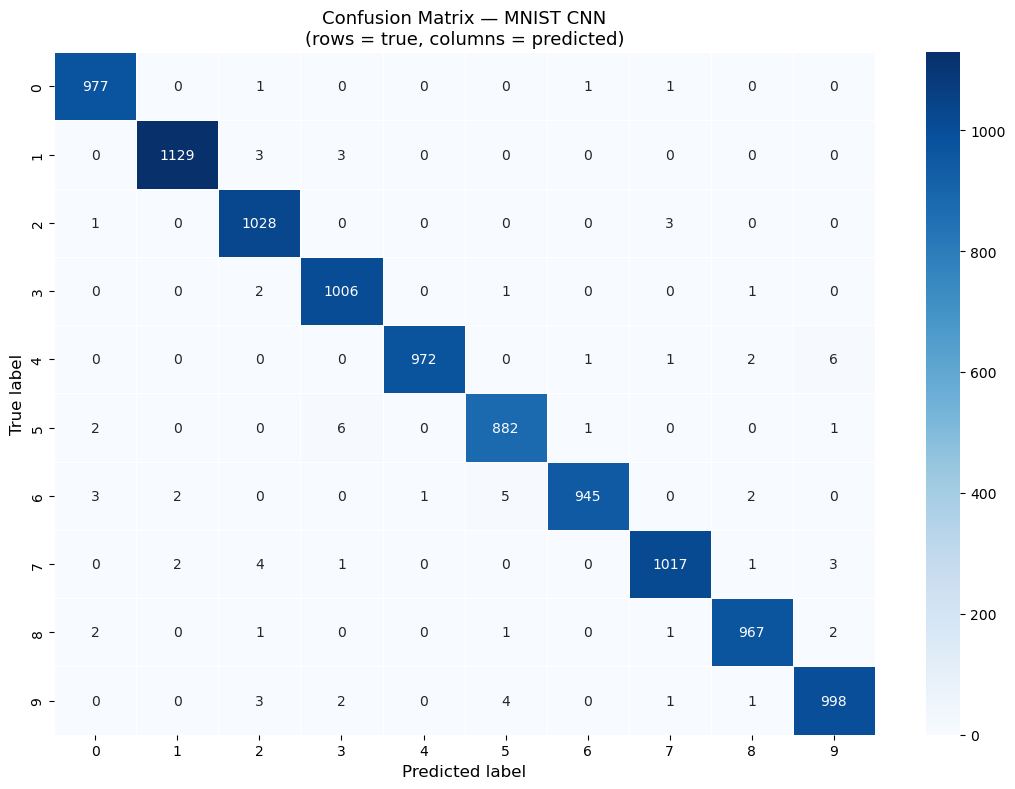

Top confused digit pairs:
  True=5 predicted as 3: 6 times
  True=4 predicted as 9: 6 times
  True=6 predicted as 5: 5 times
  True=9 predicted as 5: 4 times
  True=7 predicted as 2: 4 times


In [14]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(11, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10),
    linewidths=0.4,
    linecolor='white'
)
plt.xlabel('Predicted label', fontsize=12)
plt.ylabel('True label', fontsize=12)
plt.title('Confusion Matrix — MNIST CNN\n(rows = true, columns = predicted)', fontsize=13)
plt.tight_layout()
plt.show()

# Print the top-5 most confused pairs
print("Top confused digit pairs:")
pairs = []
for i in range(10):
    for j in range(10):
        if i != j:
            pairs.append((cm[i,j], i, j))
for count, true, pred in sorted(pairs, reverse=True)[:5]:
    print(f"  True={true} predicted as {pred}: {count} times")

Total errors: 79 out of 10,000


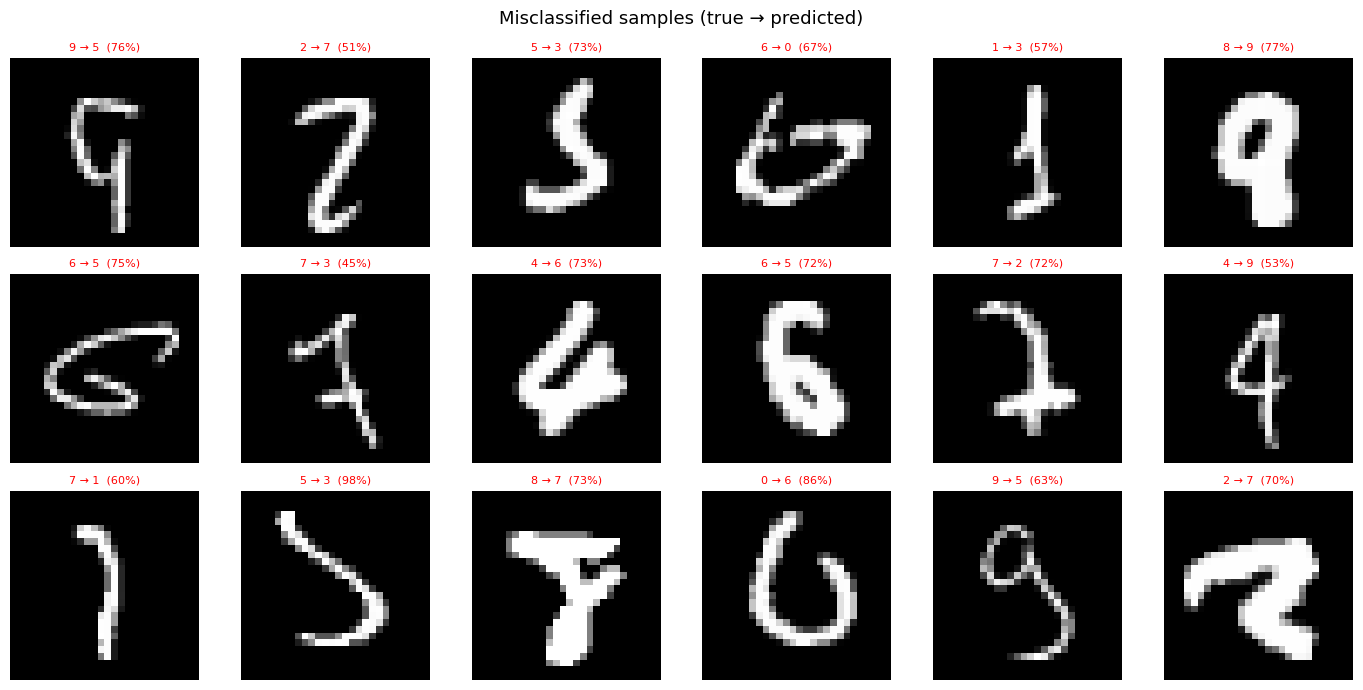

In [15]:
# ── Visualise misclassified images ────────────────────────────────────────────
# These are the images where model.predict() was wrong.
# Visual inspection often reveals truly ambiguous handwriting.

error_indices = np.where(y_pred != y_test)[0]
print(f"Total errors: {len(error_indices)} out of 10,000")

fig, axes = plt.subplots(3, 6, figsize=(14, 7))
plt.suptitle('Misclassified samples (true → predicted)', fontsize=13)

for i, ax in enumerate(axes.flat):
    idx    = error_indices[i]
    image  = X_test[idx, :, :, 0]
    true   = y_test[idx]
    pred   = y_pred[idx]
    conf   = y_pred_probs[idx, pred]

    ax.imshow(image, cmap='gray', interpolation='nearest')
    ax.set_title(f"{true} → {pred}  ({conf:.0%})", fontsize=8,
                 color='red' if true != pred else 'green')
    ax.axis('off')

plt.tight_layout()
plt.show()

---

# Step 7 — Prediction

## Theory

After training and evaluation, the model is ready for **inference** — making predictions on new images.

The model outputs a **softmax probability vector** of length 10. Each value is the model's confidence  
that the input image belongs to that class. The predicted digit is the class with the highest probability.

In production, you would also check the **confidence score** — if `max(probs)` is below a threshold  
(e.g., 0.8), you might flag the prediction for human review rather than trusting it blindly.

## Mathematics

**Inference:**

$$\hat{y} = f_{\theta}(X) \in \mathbb{R}^{10} \qquad \text{(softmax probabilities)}$$

$$\text{Predicted class} = \arg\max_k \hat{y}_k$$

$$\text{Confidence} = \max_k \hat{y}_k \in (0, 1]$$

Example output vector for an image of '3':

$$\hat{y} = [0.00,\; 0.00,\; 0.01,\; \mathbf{0.97},\; 0.00,\; 0.01,\; 0.00,\; 0.00,\; 0.01,\; 0.00]$$
$$\Rightarrow \text{class} = 3, \quad \text{confidence} = 97\%$$

## TensorFlow implementation

Prediction on index 42:


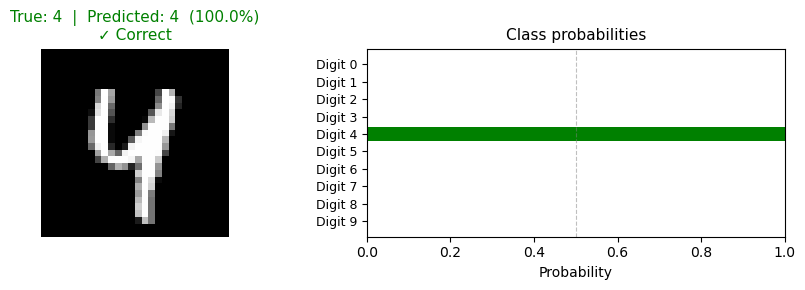

In [16]:
def predict_and_show(index, X=X_test, y=y_test):
    """
    Runs inference on a single image and displays:
      - left panel : the image with true label and prediction
      - right panel: horizontal bar chart of all 10 class probabilities
    
    Parameters
    ----------
    index : int
        Index into X (0 to len(X)-1)
    X     : array-like, shape (N, 28, 28, 1)
    y     : array-like, shape (N,)
    """
    img   = X[index]                            # (28, 28, 1)
    inp   = img[tf.newaxis, ...]                # (1, 28, 28, 1) — add batch dim

    # Forward pass — training=False disables Dropout and BatchNorm updates
    probs = model.predict(inp, verbose=0)[0]    # (10,)
    pred  = int(probs.argmax())                 # predicted class index
    conf  = float(probs.max())                  # confidence
    true  = int(y[index])

    correct = (pred == true)
    status  = '✓ Correct' if correct else '✗ Wrong'
    color   = 'green' if correct else 'red'

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))

    # Left: image
    ax1.imshow(img[:, :, 0], cmap='gray', interpolation='nearest')
    ax1.set_title(
        f"True: {true}  |  Predicted: {pred}  ({conf:.1%})\n{status}",
        fontsize=11, color=color
    )
    ax1.axis('off')

    # Right: probability bars
    bar_colors = ['green' if i == pred else 'steelblue' for i in range(10)]
    ax2.barh(range(10), probs, color=bar_colors, edgecolor='none')
    ax2.axvline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    ax2.set_yticks(range(10))
    ax2.set_yticklabels([f'Digit {i}' for i in range(10)], fontsize=9)
    ax2.set_xlabel('Probability', fontsize=10)
    ax2.set_xlim(0, 1)
    ax2.set_title('Class probabilities', fontsize=11)
    ax2.invert_yaxis()

    plt.tight_layout()
    plt.show()

    return probs


# ── Try a few examples ────────────────────────────────────────────────────────
print("Prediction on index 42:")
_ = predict_and_show(42)

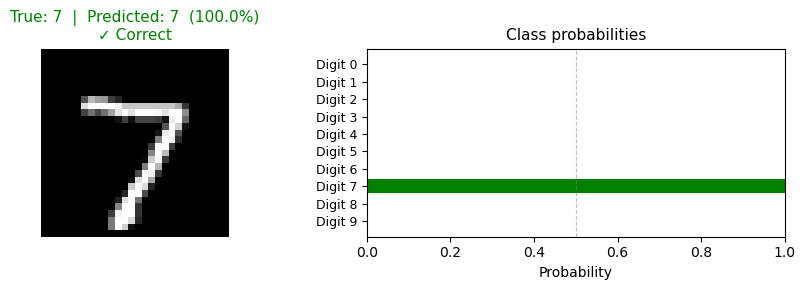

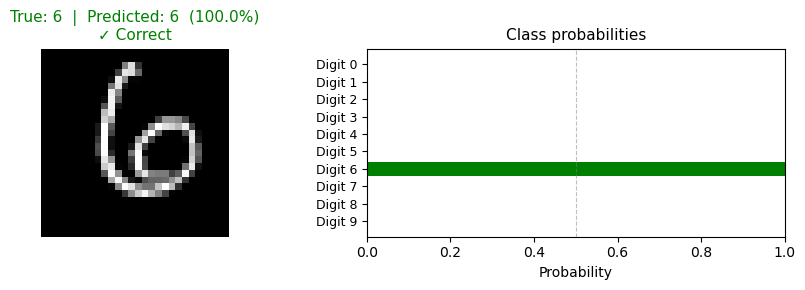

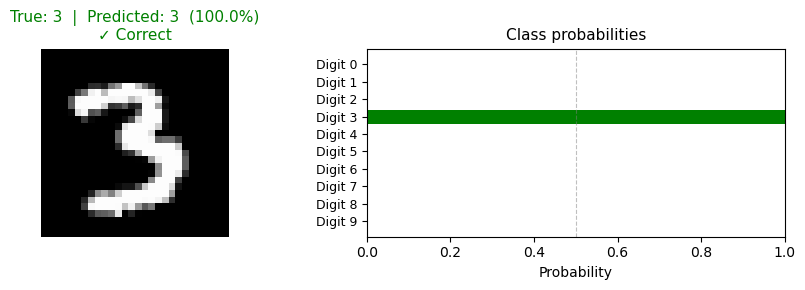

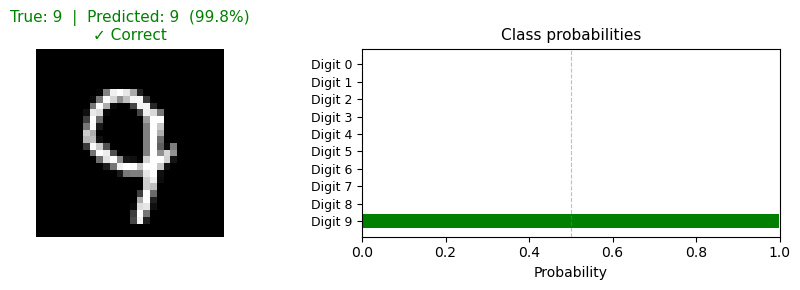

In [17]:
# Try more examples — change the index to explore
for idx in [0, 100, 500, 999]:
    _ = predict_and_show(idx)

In [18]:
# ── Batch prediction ──────────────────────────────────────────────────────────
# batch_size=256 is efficient on GPU: avoids kernel launch overhead per sample.
all_probs = model.predict(X_test, batch_size=256, verbose=0)  # (10000, 10)
all_preds = all_probs.argmax(axis=1)                          # (10000,)

final_acc = (all_preds == y_test).mean()
print(f"Final accuracy on all 10,000 test images: {final_acc:.4f}  ({final_acc*100:.2f}%)")
print(f"Total correct     : {(all_preds == y_test).sum():,}")
print(f"Total incorrect   : {(all_preds != y_test).sum():,}")

# Per-class accuracy
print("\nPer-class accuracy:")
for digit in range(10):
    mask     = y_test == digit
    acc      = (all_preds[mask] == y_test[mask]).mean()
    bar      = '█' * int(acc * 30)
    print(f"  Digit {digit}: {acc:.4f}  {bar}")

Final accuracy on all 10,000 test images: 0.9921  (99.21%)
Total correct     : 9,921
Total incorrect   : 79

Per-class accuracy:
  Digit 0: 0.9969  █████████████████████████████
  Digit 1: 0.9947  █████████████████████████████
  Digit 2: 0.9961  █████████████████████████████
  Digit 3: 0.9960  █████████████████████████████
  Digit 4: 0.9898  █████████████████████████████
  Digit 5: 0.9888  █████████████████████████████
  Digit 6: 0.9864  █████████████████████████████
  Digit 7: 0.9893  █████████████████████████████
  Digit 8: 0.9928  █████████████████████████████
  Digit 9: 0.9891  █████████████████████████████


In [19]:
# ── Save the model ────────────────────────────────────────────────────────────
# The .keras format saves: architecture + weights + optimiser state.
# You can reload it anywhere with tf.keras.models.load_model().
model.save('mnist_cnn_final.keras')
print("Model saved to: mnist_cnn_final.keras")

# How to reload:
# loaded_model = tf.keras.models.load_model('mnist_cnn_final.keras')
# loaded_model.evaluate(X_test, y_test)

Model saved to: mnist_cnn_final.keras


---

# Summary

## What we built

A LeNet-style CNN that classifies handwritten digits with ~99.2% accuracy.

## Full pipeline recap

| Step | Action | Key detail |
|------|--------|------------|
| 1 | Load data | `tf.keras.datasets.mnist.load_data()` |
| 2 | Explore | Visualise samples, check pixel stats and class balance |
| 3 | Normalise | Divide by 255, add channel dim `(N,28,28)→(N,28,28,1)` |
| 4 | Build model | 2× Conv+BN+Pool+Dropout → Dense(128) → Dense(10,softmax) |
| 5 | Train | Adam, batch=128, EarlyStopping + ReduceLROnPlateau |
| 6 | Evaluate | Test accuracy, confusion matrix, classification report |
| 7 | Predict | Softmax probs → argmax → predicted class + confidence |

## Key mathematics

| Formula | Meaning |
|---------|---------|
| $Z[i,j,f] = \sum W \cdot X + b$ | Convolution at position (i,j) |
| $A = \max(0, Z)$ | ReLU activation |
| $\hat{y}_k = \exp(z_k)/\sum_j \exp(z_j)$ | Softmax output |
| $\mathcal{L} = -\log(\hat{y}_{y_{\text{true}}})$ | Cross-entropy loss |
| $W_t = W_{t-1} - \alpha \cdot \hat{m}_t / \sqrt{\hat{v}_t}$ | Adam weight update |

---

## Next steps

If you want to go further with this project:

- **Data augmentation** — random rotations, shifts, and zooms to improve generalisation
- **Deeper architecture** — try VGG-style blocks or ResNet skip connections
- **Learning rate finder** — sweep LR over a range to find the optimal starting value
- **Grad-CAM** — visualise which pixels the model looks at when making predictions
- **Deploy** — wrap the model in a Flask/FastAPI endpoint or a Gradio demo
- **CIFAR-10** — the natural next step: 32×32 colour images across 10 object classes

---

*Built as a deep learning learning project. Fork, experiment, and extend.*